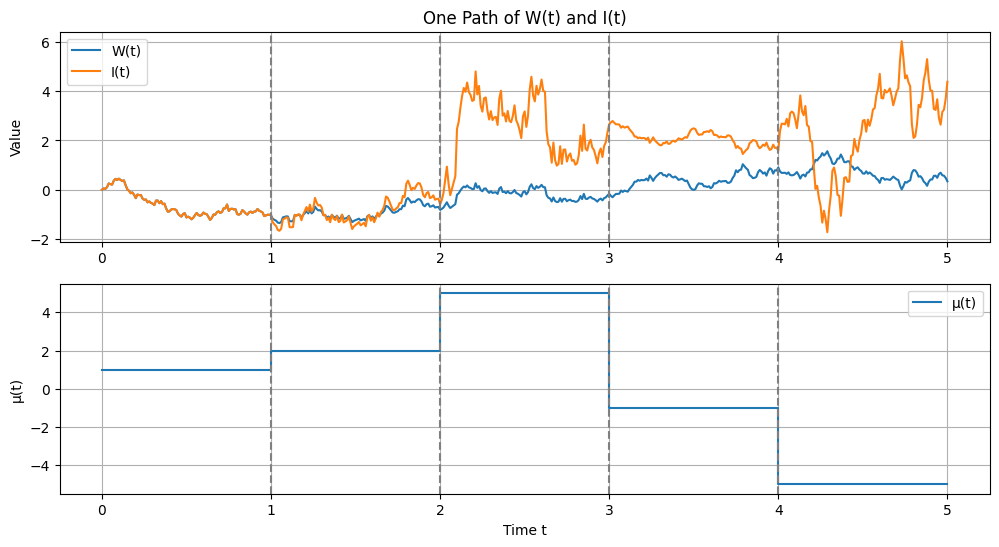

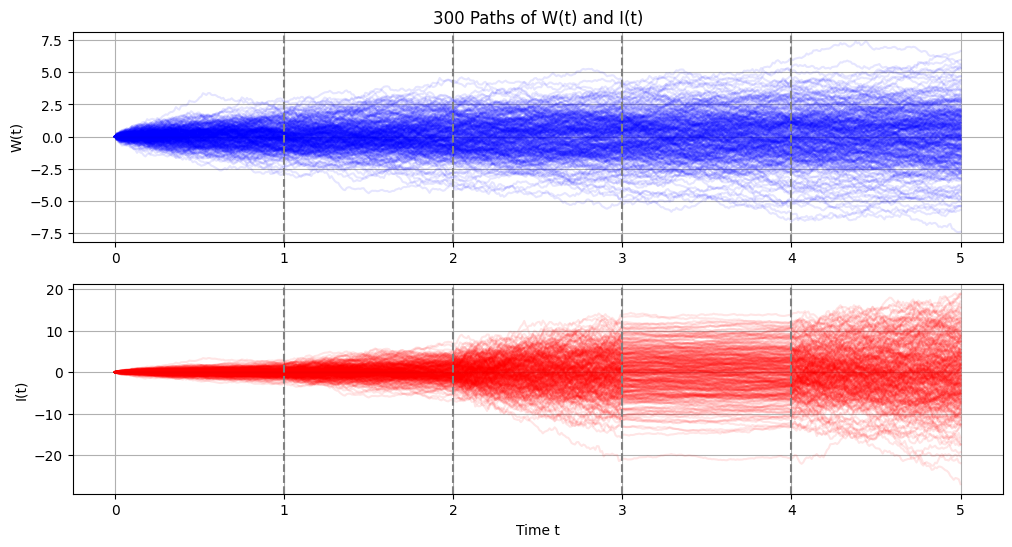

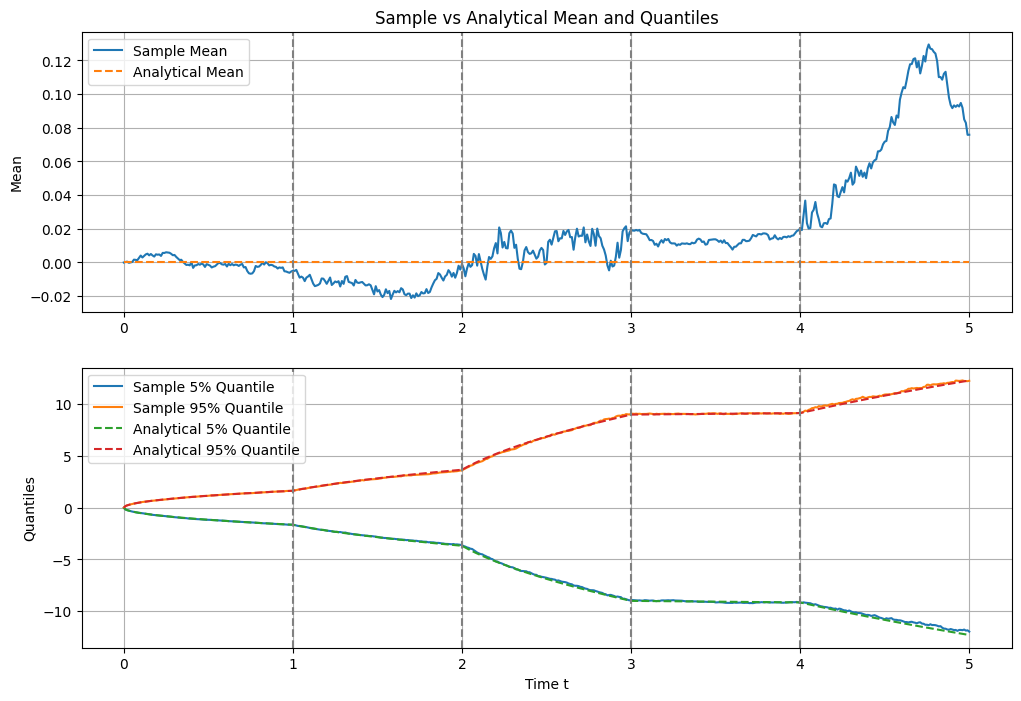

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T = 5.0
dt = 0.01
n_steps = int(T / dt)
t = np.linspace(0, T, n_steps + 1)

# Define mu(t)
def mu(t):
    if t < 1:
        return 1
    elif t < 2:
        return 2
    elif t < 3:
        return 5
    elif t < 4:
        return -1
    else:
        return -5

mu_vec = np.array([mu(ti) for ti in t])

# Part (a): Simulate one path
np.random.seed(42)  # For reproducibility
dW = np.random.normal(0, np.sqrt(dt), n_steps)
W = np.cumsum(dW)
W = np.insert(W, 0, 0)  # W(0) = 0

I = np.zeros(n_steps + 1)
for i in range(1, n_steps + 1):
    I[i] = I[i-1] + mu_vec[i-1] * (W[i] - W[i-1])

# Plot for part (a)
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, W, label='W(t)')
plt.plot(t, I, label='I(t)')
plt.axvline(x=1, linestyle='--', color='gray')
plt.axvline(x=2, linestyle='--', color='gray')
plt.axvline(x=3, linestyle='--', color='gray')
plt.axvline(x=4, linestyle='--', color='gray')
plt.ylabel('Value')
plt.legend()
plt.title('One Path of W(t) and I(t)')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.step(t, mu_vec, where='post', label='μ(t)')
plt.axvline(x=1, linestyle='--', color='gray')
plt.axvline(x=2, linestyle='--', color='gray')
plt.axvline(x=3, linestyle='--', color='gray')
plt.axvline(x=4, linestyle='--', color='gray')
plt.ylabel('μ(t)')
plt.xlabel('Time t')
plt.legend()
plt.grid(True)
plt.show()

# Part (b): Simulate 300 paths
n_paths = 300
W_paths = np.zeros((n_paths, n_steps + 1))
I_paths = np.zeros((n_paths, n_steps + 1))

for j in range(n_paths):
    dW = np.random.normal(0, np.sqrt(dt), n_steps)
    W_paths[j] = np.insert(np.cumsum(dW), 0, 0)
    for i in range(1, n_steps + 1):
        I_paths[j, i] = I_paths[j, i-1] + mu_vec[i-1] * (W_paths[j, i] - W_paths[j, i-1])

# Plot for part (b)
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
for j in range(n_paths):
    plt.plot(t, W_paths[j], color='blue', alpha=0.1)
plt.axvline(x=1, linestyle='--', color='gray')
plt.axvline(x=2, linestyle='--', color='gray')
plt.axvline(x=3, linestyle='--', color='gray')
plt.axvline(x=4, linestyle='--', color='gray')
plt.ylabel('W(t)')
plt.title('300 Paths of W(t) and I(t)')
plt.grid(True)

plt.subplot(2, 1, 2)
for j in range(n_paths):
    plt.plot(t, I_paths[j], color='red', alpha=0.1)
plt.axvline(x=1, linestyle='--', color='gray')
plt.axvline(x=2, linestyle='--', color='gray')
plt.axvline(x=3, linestyle='--', color='gray')
plt.axvline(x=4, linestyle='--', color='gray')
plt.ylabel('I(t)')
plt.xlabel('Time t')
plt.grid(True)
plt.show()

# Part (c): Analytical and sample statistics
n_paths_large = 10000  # Use more paths for better accuracy
I_paths_large = np.zeros((n_paths_large, n_steps + 1))

for j in range(n_paths_large):
    dW = np.random.normal(0, np.sqrt(dt), n_steps)
    W_temp = np.insert(np.cumsum(dW), 0, 0)
    for i in range(1, n_steps + 1):
        I_paths_large[j, i] = I_paths_large[j, i-1] + mu_vec[i-1] * (W_temp[i] - W_temp[i-1])

# Sample statistics
sample_mean = np.mean(I_paths_large, axis=0)
sample_quantile_5 = np.percentile(I_paths_large, 5, axis=0)
sample_quantile_95 = np.percentile(I_paths_large, 95, axis=0)

# Analytical statistics
def variance(t):
    if t < 1:
        return t
    elif t < 2:
        return 1 + 4*(t-1)
    elif t < 3:
        return 5 + 25*(t-2)
    elif t < 4:
        return 30 + 1*(t-3)
    else:
        return 31 + 25*(t-4)

variance_vec = np.array([variance(ti) for ti in t])
analytical_mean = np.zeros_like(t)
analytical_quantile_5 = -1.645 * np.sqrt(variance_vec)
analytical_quantile_95 = 1.645 * np.sqrt(variance_vec)

# Plot for part (c)
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t, sample_mean, label='Sample Mean')
plt.plot(t, analytical_mean, label='Analytical Mean', linestyle='--')
plt.axvline(x=1, linestyle='--', color='gray')
plt.axvline(x=2, linestyle='--', color='gray')
plt.axvline(x=3, linestyle='--', color='gray')
plt.axvline(x=4, linestyle='--', color='gray')
plt.ylabel('Mean')
plt.legend()
plt.title('Sample vs Analytical Mean and Quantiles')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, sample_quantile_5, label='Sample 5% Quantile')
plt.plot(t, sample_quantile_95, label='Sample 95% Quantile')
plt.plot(t, analytical_quantile_5, label='Analytical 5% Quantile', linestyle='--')
plt.plot(t, analytical_quantile_95, label='Analytical 95% Quantile', linestyle='--')
plt.axvline(x=1, linestyle='--', color='gray')
plt.axvline(x=2, linestyle='--', color='gray')
plt.axvline(x=3, linestyle='--', color='gray')
plt.axvline(x=4, linestyle='--', color='gray')
plt.ylabel('Quantiles')
plt.xlabel('Time t')
plt.legend()
plt.grid(True)
plt.show()

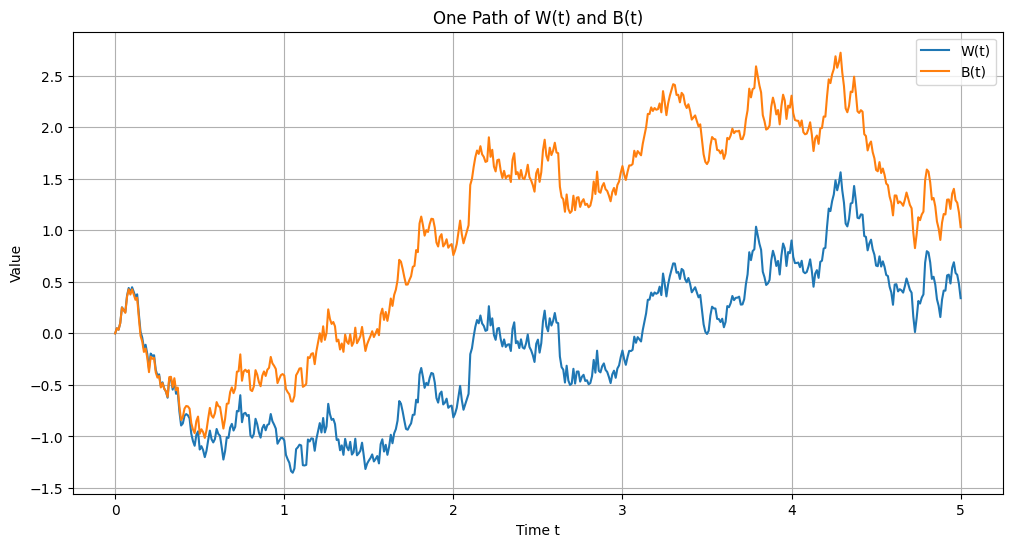

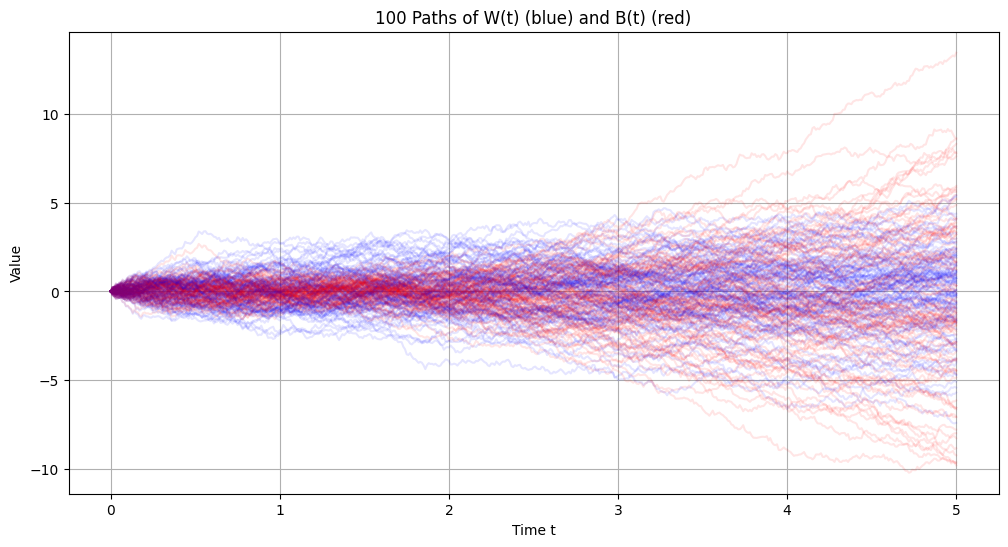

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T = 5.0
dt = 0.01
n_steps = int(T / dt)
t = np.linspace(0, T, n_steps + 1)

# Initialize arrays
W = np.zeros(n_steps + 1)
I = np.zeros(n_steps + 1)
B = np.zeros(n_steps + 1)

# Simulate one path
np.random.seed(42)
dW = np.random.normal(0, np.sqrt(dt), n_steps)
W[1:] = np.cumsum(dW)
for i in range(1, n_steps + 1):
    I[i] = I[i-1] + W[i-1] * dt
B = W - I

# Plot one path
plt.figure(figsize=(12, 6))
plt.plot(t, W, label='W(t)')
plt.plot(t, B, label='B(t)')
plt.xlabel('Time t')
plt.ylabel('Value')
plt.legend()
plt.title('One Path of W(t) and B(t)')
plt.grid(True)
plt.show()

# Simulate 100 paths
n_paths = 100
W_paths = np.zeros((n_paths, n_steps + 1))
B_paths = np.zeros((n_paths, n_steps + 1))

for j in range(n_paths):
    dW = np.random.normal(0, np.sqrt(dt), n_steps)
    W_paths[j, 1:] = np.cumsum(dW)
    I_path = np.zeros(n_steps + 1)
    for i in range(1, n_steps + 1):
        I_path[i] = I_path[i-1] + W_paths[j, i-1] * dt
    B_paths[j] = W_paths[j] - I_path

# Plot multiple paths
plt.figure(figsize=(12, 6))
for j in range(n_paths):
    plt.plot(t, W_paths[j], color='blue', alpha=0.1)
    plt.plot(t, B_paths[j], color='red', alpha=0.1)
plt.xlabel('Time t')
plt.ylabel('Value')
plt.title('100 Paths of W(t) (blue) and B(t) (red)')
plt.grid(True)
plt.show()